#**Using Health Indicators to Predict Diabetes**
###_Collaborators: Andrew Liu, Ethan Liu, Kaelyn Funchion, Jane Oh, James Lin_
---
**Contributions:**

**Ethan**: Worked on the data cleaning portion (A) and wrote most of the text for the initial exploratory data analysis (C) and ML primary analysis (D)

**James**: Worked on the logistic regression and SVM models (D) and wrote the analysis of the model’s results on the training data (E). Also created plots of coefficient weights and confusion matrices (F).

**Kaelyn**: Helped with the Data Exploration (C) by creating graphs on different features and their density compared with the presence of diabetes. I wrote several of the analysis of the visualizations and the results presented, along with the conclusion of our data (G).

**Jane**: Worked on 2-sample T test (C), project direction (A), and conclusion (G). Helped for data curation as well as exploration for data analysis(C).

**Andrew**: Worked on project direction and introduction, as well as data curation and research behind the context of the dataset (A, B).


---

###**Introduction**

The purpose of this project is to analyze a dataset containing patients’ health factors and their diabetic status. This analysis will ultimately be used to predict the presence of diabetes in patients based on several health indicators, such as blood pressure, cholesterol levels, BMI, age, etc. The question we are trying to answer is: which health indicators are most predictive of diabetes in a patient? Predicting diabetes in patients is extremely helpful as early detection largely assists patient treatment.

Studying diabetes is important as it is one of the most prevalent chronic diseases in the US. Furthermore, diabetes can lead to other severe health complications such as heart disease and kidney failure. Being able to accurately detect diabetes early often leads to reversal and sufficient treatment of diabetes in patients, leading to healthier and more convenient lifestyles.

This tutorial will explore the data science life cycle as listed:
1. Data curation
2. Exploratory data analysis
3. Primary analysis
4. Visualization
5. Insights and Conclusions.



In [126]:
## Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import tukey_hsd
from scipy.stats import mannwhitneyu
from google.colab import drive
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

---
#**Data Curation**
The dataset we chose is preprocessed and contains 70,692 entries, and is composed of a 50/50 split between people with diabetes and people with no diabetes along with 21 selected health indicators. This dataset is based on the BRFSS (Behavioral Risk Factor Surveillance System), a telephone survey collected annually by the CDC, collecting responses from over 400,000 Americans each year. We chose this dataset due to its large number of entries and its credibility, as well as its central focus on diabetes. We are using this preprocessed dataset over the raw dataset because we understand that, while the dataset is large and nationally representative, it is based on self-reported survey data and may contain reporting bias and error. The BRFSS 2015 data were filtered to 21 selected health indicators, then rows with missing values were dropped. Remaining responses were recorded using the CDC codebook: yes/no items became 0/1, ordinal variables were kept as numeric scales, and “don’t know/refused/missing” codes (7/77, 9/99, 14) were removed. BMI was converted from BMI×100 to BMI, columns were renamed for readability, and the result was saved as both a 3-class dataset and binary versions, including a balanced 50/50 split, which we decided to use for this project. The dataset can be downloaded here:
#[**DATASET**](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data?select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv)



In [127]:
## Preparing the dataset for analysis

drive.mount('/content/drive/')

df = pd.read_csv('/content/drive/My Drive/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


###**Before the original author cleaned the dataset, all the BMI values were multiplied by 100. To "dirty" the dataset, we reverted the  BMI rows back to their original pre-cleaned value. We also selected 50 random rows to insert NA values as part of our dirtying process as well.**

___

## **Reverting BMI, Making 50 random rows contain NA values**

In [128]:
df['BMI'] = (df['BMI'] * 100).astype(int)

np.random.seed(42)
nan_rows = np.random.choice(df.index, size = 50, replace = False)
cols = [c for c in df.columns]

## **For each row, selects a random number of columns (1-3) to turn to NA**


In [129]:
for i in nan_rows:
    n_cols_to_null = np.random.randint(1, 4)
    cols_to_null = np.random.choice(cols, size = n_cols_to_null, replace = False)
    df.loc[i, cols_to_null] = np.nan

## **Clean and Display the Dataset**
___

In [130]:
df['BMI'] = df['BMI'].div(100).round(0)
df = df.dropna()
print(f"Shape of the Dataset: {df.shape}")

print("\nDataset Head")
display(df.head())

Shape of the Dataset: (70642, 22)

Dataset Head


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


##**Exploratory Data Analysis**
___

###The dataset includes 21 different features, ranging from high blood pressure and high cholesterol to education and income. Seven of the 21 features (BMI, General Health, Mental Health, Physical Health, Age, Education, and Income) are measured based on ordinals, and the rest are measured based on binary classification.

###An explanation for each of the ordinal scales is as follows:
* BMI (body mass index) measured from 12-98

* General Health is measured on a scale of 1-5, with 1 being excellent and 5 being poor

* Mental Health is measured on a 30-day scale, with the entry being the number of days the person experienced poor mental health

* Physical Health is measured on a 30-day scale, with the entry being the number of days the person experienced poor physical health

* Age is measured on a scale of 1-13 based on the AGE5YR age category system (each number corresponds to a range of ages that ascend from age 18 to 80+)

* Education level is measured on a scale of 1-6 based on the EDUCA category system (going from 1: Never attended school or only kindergarten to 6: College 4 years or more)

* Income level is measured on a scale of 1-8 based on the INCOME2 category system (going from 1: earning less than \$10,000 a year to 8: earning $75,000 or more a year)

###We then decided to graph each of these 21 features separately. When looking at the graphs, there are five features that have an obvious visual separation between classes: <font color='red'><b>BMI, General Health, Age, High Blood Pressure, and High Cholesterol.</b></font> In general, the distribution of diabetes versus no diabetes for each of these features had a large amount of variation, depending on the values. For instance, the frequency of no diabetes was more than double the frequency of diabetes for people with high blood pressure, and vice versa for people without high blood pressure.

###Because of the disparity, we decided to dive deeper into three features in particular: High Cholesterol, BMI, and Age, conducting a chi-squared contingency test, two-sample t-test, and Mann-Whitney U test for these features, respectively.


#**Chi-Squared Contingency Test**
___
###<font color = #9E1702> H₀: There is no association between diabetes and high cholesterol</font>

###<font color = #405C3D> Hₐ: There is a an association between diabetes and high cholesterol</font>

Chi square: 5906.684550221073
P-value: 0.0
Degree of freedom: 1
Expected freq: [[16751.52572124 18568.47427876]
 [16752.47427876 18569.52572124]]


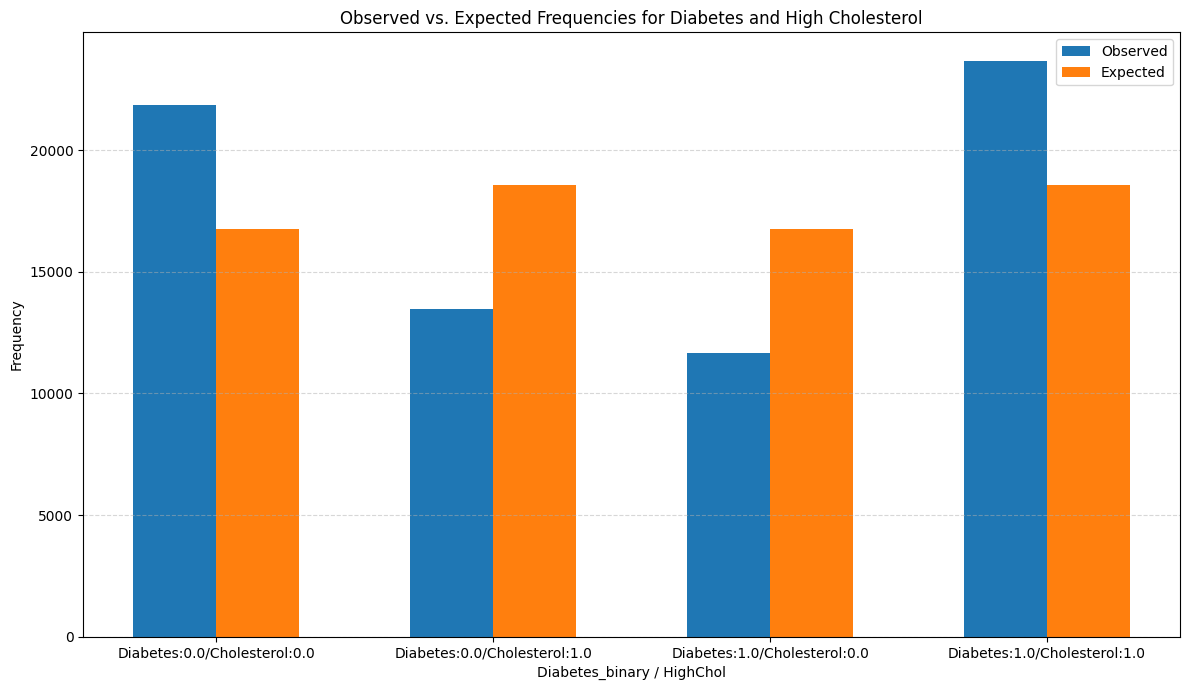

In [131]:
cont = pd.crosstab(df['Diabetes_binary'], df['HighChol'])
chi, p_value, deg, ef = stats.chi2_contingency(cont)

print(f"Chi square: {chi}")
print(f"P-value: {p_value}")
print(f"Degree of freedom: {deg}")
print(f"Expected freq: {ef}")

observed_values = cont.values.flatten()
expected_values = ef.flatten()
categories = [f'Diabetes:{d}/Cholesterol:{c}' for d in cont.index for c in cont.columns]

x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - 0.3/2, observed_values, 0.3, label='Observed')
rects2 = ax.bar(x + 0.3/2, expected_values, 0.3, label='Expected')

ax.set_ylabel('Frequency')
ax.set_xlabel('Diabetes_binary / HighChol')
ax.set_title('Observed vs. Expected Frequencies for Diabetes and High Cholesterol')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

###Using the chi square contingency test, it can be concluded that there is a <font color = #408040> statistically significant </font> association between high cholesterol and diabetes. This can be concluded due to the extremely high chi square statistic and low p-value (less than alpha value of 0.05) returned by running the chi square contingency test on the contingency table containing diabetes and high cholesterol statistics.
___

#**Two Sample T-Test**
___
###<font color = #9E1702> H₀: The mean BMI is the same for both groups</font>

###<font color = #405C3D> Hₐ: The mean BMI is different for the groups</font>

T-statistic: -81.55836795397737
P-value: 0.0


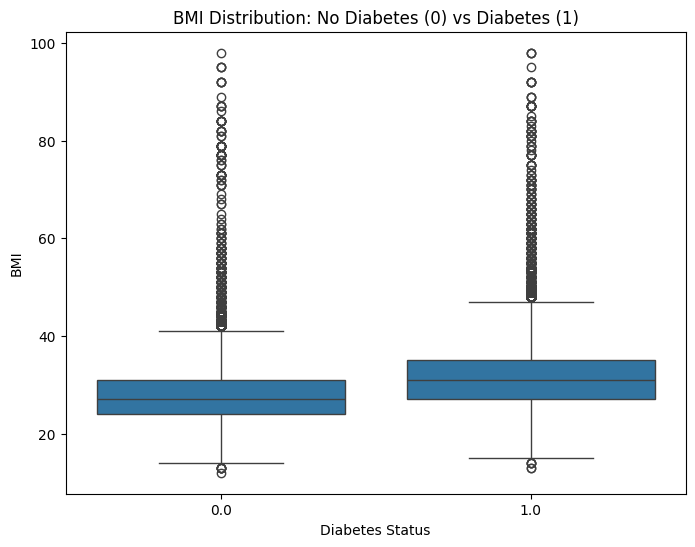

In [132]:
from scipy.stats import ttest_ind

df_filtered = df[df['Diabetes_binary'].isin([0, 1])]
df_filtered = df_filtered[['Diabetes_binary', 'BMI']].dropna()
group_no_diabetes = df_filtered[df_filtered['Diabetes_binary'] == 0]['BMI']
group_diabetes = df_filtered[df_filtered['Diabetes_binary'] == 1]['BMI']
t_stat, p_value = ttest_ind(group_no_diabetes, group_diabetes, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)

plt.figure(figsize=(8,6))
sns.boxplot(x='Diabetes_binary', y='BMI', data=df_filtered)

plt.title("BMI Distribution: No Diabetes (0) vs Diabetes (1)")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.show()

###A two-sample t-test was conducted to compare BMI between individuals with no diabetes (0) and those with diabetes (1). The p-value is effectively 0, which is far below 0.05. Therefore, we reject the null hypothesis and conclude that there is a <font color = #408040> statistically significant </font> difference in BMI between the two groups. Individuals with diabetes have higher BMI on average.
___

#**Mann-Whitney U Test**
___
###<font color = #9E1702> H₀: There is no difference in the distribution of age between patients with diabetes and patients without diabetes </font>

###<font color = #405C3D> Hₐ: There is a difference in the distribution of age between patients with diabetes and patients without diabetes </font>

## **<font color = red>! Note that age is based on 13 different age ranges with a 1 representing people between the ages of 18 and 24, and a 13 representing 80+ !</font>**

0.0


Text(0.5, 1.0, 'Mean Age_Group based on Presence of Diabetes')

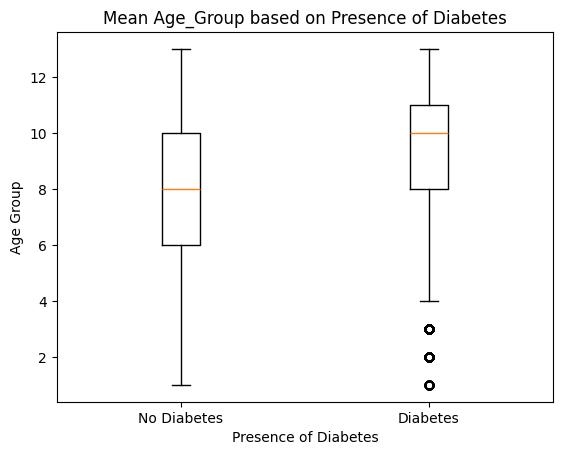

In [133]:
df_nodiabetes = df[df['Diabetes_binary'] == 0]
df_diabetes = df[df['Diabetes_binary'] == 1]

pval = mannwhitneyu(df_diabetes['Age'], df_nodiabetes['Age']).pvalue

print(pval)
plt.boxplot([df_nodiabetes['Age'],df_diabetes['Age']],tick_labels=["No Diabetes","Diabetes"])
plt.ylabel("Age Group")
plt.xlabel("Presence of Diabetes")
plt.title("Mean Age_Group based on Presence of Diabetes")

###Based on the conclusion of the Mann-Whitney U test, which gave a P-value of 0.0 which is less than the significance level 0.05 we reject the null hypothesis, and can conclude that there is a <font color = #408040> statistically significant </font> difference in the distribution of age between patients with diabetes and patients without diabetes. We can conclude that there is significant differences of average age groups among the 2 different indicator levels, no diabetes and diabetes. Furthermore, if we look at our boxplot we can see that the median age group increases as we move from no diabetes to diabetes. With no diabetes having a median age group value of 8, and diabetes having a median of 10, along with several outliers at age groups 1,2, and 3.

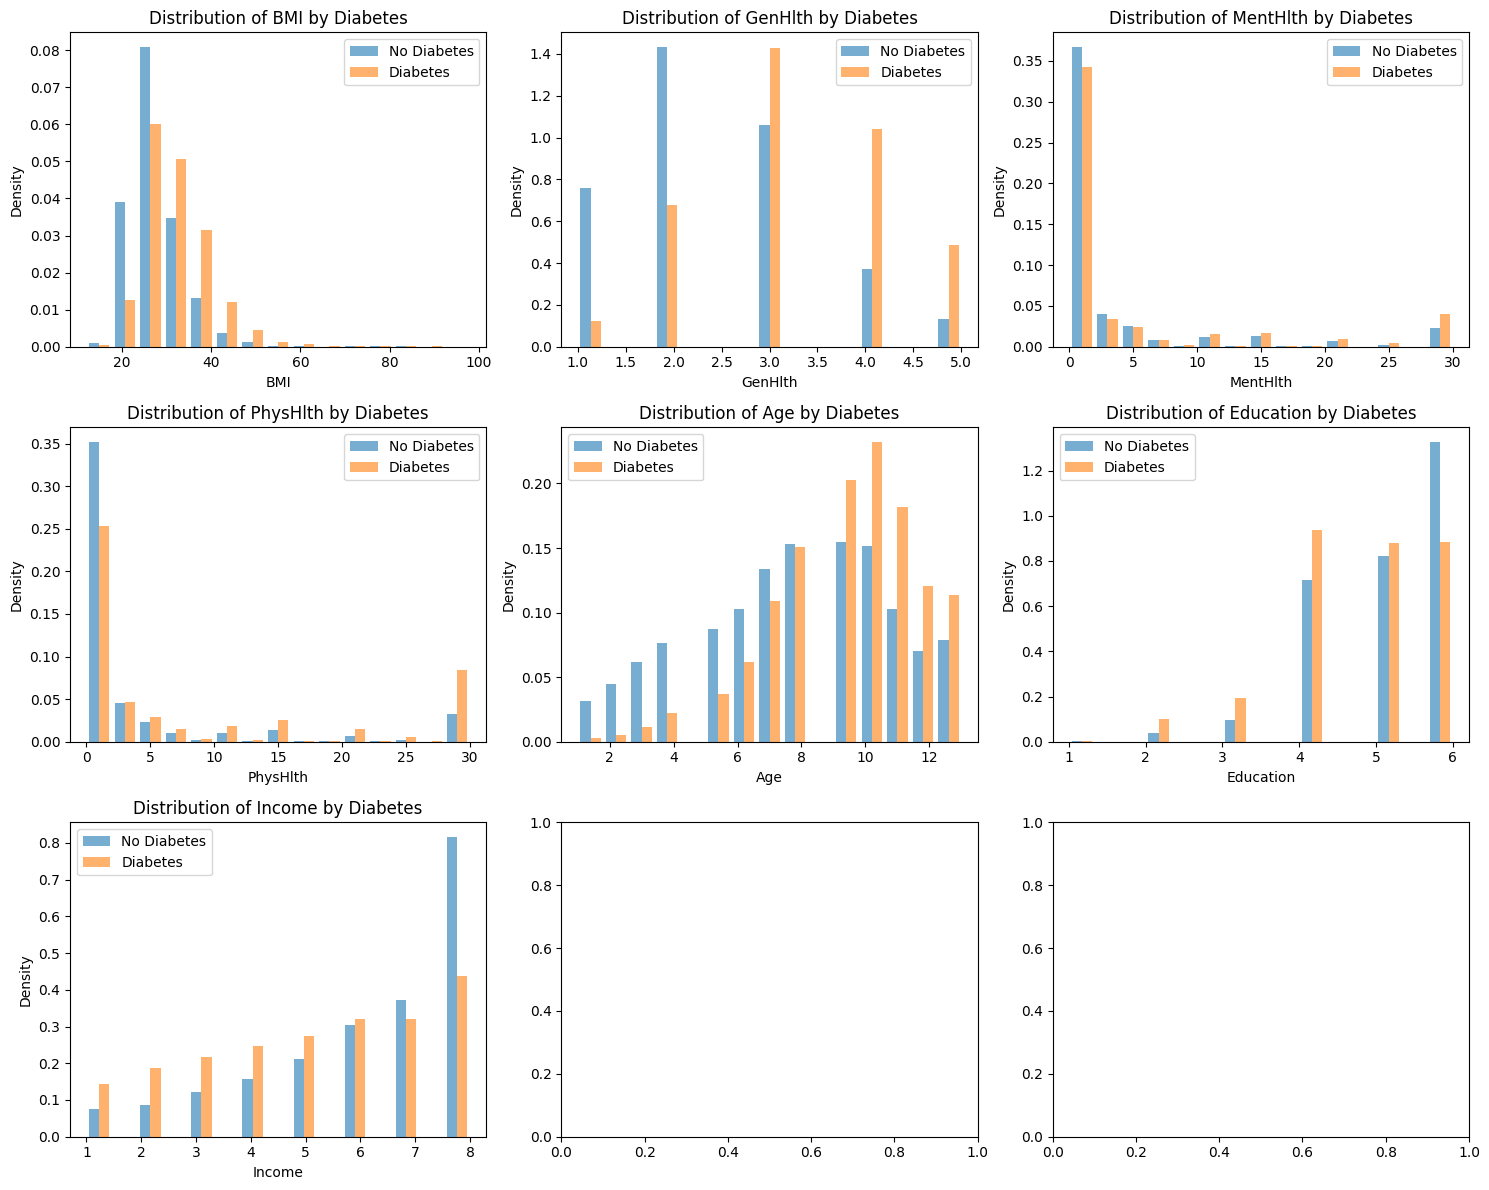

In [134]:
histogram_pd = df[['BMI','GenHlth','MentHlth','PhysHlth','Age','Education','Income']]
histogram_pd.head()
diabetes = df['Diabetes_binary']

# Create subplots
n_features = histogram_pd.shape[1]
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()


# Plot histogram for each feature
for i, feature in enumerate(histogram_pd.columns):
    ax = axes[i]

    feature_df = pd.DataFrame(histogram_pd[feature])
    feature_df['Diabetes_binary'] = diabetes

    # Plot histogram for each feature
    ax.hist([feature_df[feature][feature_df['Diabetes_binary']==0],
             feature_df[feature][feature_df['Diabetes_binary']==1]],
            bins=15, density=True, alpha=0.6, label=["No Diabetes", "Diabetes"], stacked=False)
    # Set labels and title

    ax.set_title(f'Distribution of {feature} by Diabetes')
    ax.set_xlabel(f'{feature}')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

###The graphs above show distribution of diabetes among each discrete feature present. From the graphs we can see trends like diabetes increasing as the age groups get older, or the better a person's general health is the less likely they are to have diabetes. We also see that PhysHlth, and MentHlth have a right skewed distribution with most people reporting 0 days of being sick or having poor mental health in the last 30 days.


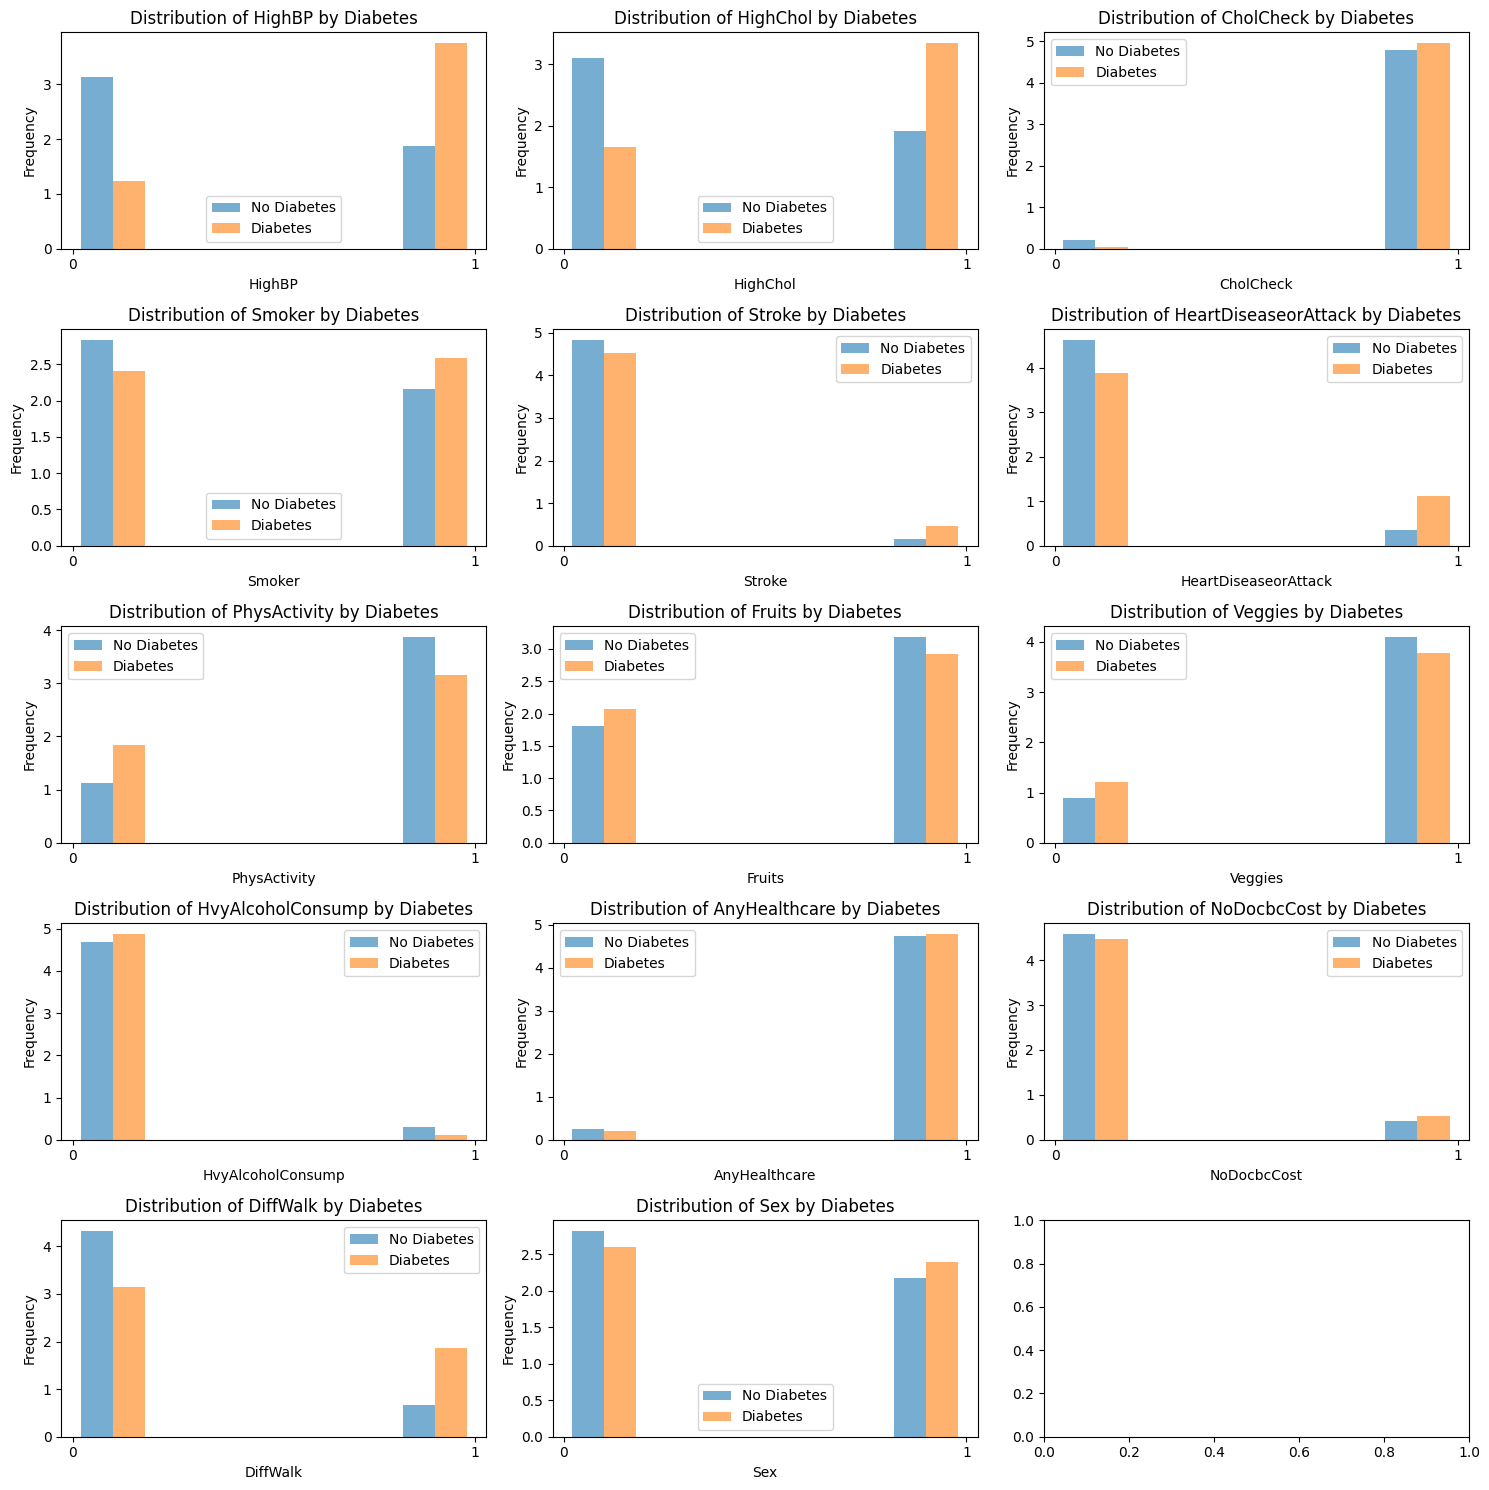

In [135]:
histogram_pd = df[['HighBP', 'HighChol', 'CholCheck','Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost','DiffWalk', 'Sex']]
histogram_pd.head()
diabetes = df['Diabetes_binary']

# Create subplots
n_features = histogram_pd.shape[1]
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

# Plot histogram for each feature
for i, feature in enumerate(histogram_pd.columns):
    ax = axes[i]


    feature_df = pd.DataFrame(histogram_pd[feature])
    feature_df['Diabetes_binary'] = diabetes
    # Plot histogram for feature
    ax.hist([feature_df[feature][feature_df['Diabetes_binary']==0],
             feature_df[feature][feature_df['Diabetes_binary']==1]],
            bins=5, density=True, alpha=0.6, label=["No Diabetes", "Diabetes"], stacked=False)

    # Set labels and title

    ax.set_title(f'Distribution of {feature} by Diabetes')
    ax.set_xlabel(f'{feature}')
    ax.set_ylabel('Frequency')
    ax.set_xticks([0,1])
    ax.legend()

plt.tight_layout()
plt.show()

###The graphs above show the distribution of each binary feature in relation to the presence of diabetes. Some key things to note are how groups like HighBP and HighChol, have a noticeable difference in the distribution of diabetes given the feature. Other things like sex, fruits, and smokers are more balanced out in terms of how many times each feature classification shows, and the distribution of diabetes among them. Finally we can see that groups like HyAlcoholConsum and AnyHealthcare, are skewed towards one side, with the majority of people surveyed responding the same.

#**Primary Analysis**
___

###Since our goal is to predict the presence of diabetes in a patient based on several features, we chose to use **classification models**.

###The models we chose to use are **Logistic Regression and SVM**, which are both useful for binary classification. For our machine learning analysis, we decided to use 14 out of the 21 features:
* BMI
* General Health
* Age
* High Blood Pressure
* High Cholesterol
* Income
* Sex
* Stroke
* Heart Disease or Attack
* Physical Activity
* Fruits
* Veggies
* Education
* Smoker
###We chose the five most visually separate features from before (BMI, General Health, Age, High Blood Pressure, High Cholesterol) and decided to include the others based on their general usefulness and appeal. We excluded 7 features (Cholesterol Check, Any Healthcare, No Doctor Because Cost, Heavy Alcohol Consumption, Mental Health, Physical Health, and Difficulty Walking) because we did not consider them to be as productive in training our model. Their graphs were either heavily weighted in one way or another (e.g., there were very few people who did not get a cholesterol checkup and very few people with heavy alcohol consumption), the feature was classified in an unusual way (e.g., Mental Health and Physical Health were classified on an unusual 30-day period), or the feature itself would likely be uninteresting or helpful to the average person.
___
#<font color = #585C8C> **Logistic Regression** </font>

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = ['BMI','GenHlth','Age','HighBP','HighChol','Income','Sex','Stroke','HeartDiseaseorAttack','Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'Education']

df['Diabetes'] = (df['Diabetes_binary'] == 1).astype(int)

X = df[features]
y = df['Diabetes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizing Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


print("Accuracy of Linear SVM Model:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy of Linear SVM Model: 0.7539811734729988
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75      7091
           1       0.75      0.77      0.76      7038

    accuracy                           0.75     14129
   macro avg       0.75      0.75      0.75     14129
weighted avg       0.75      0.75      0.75     14129



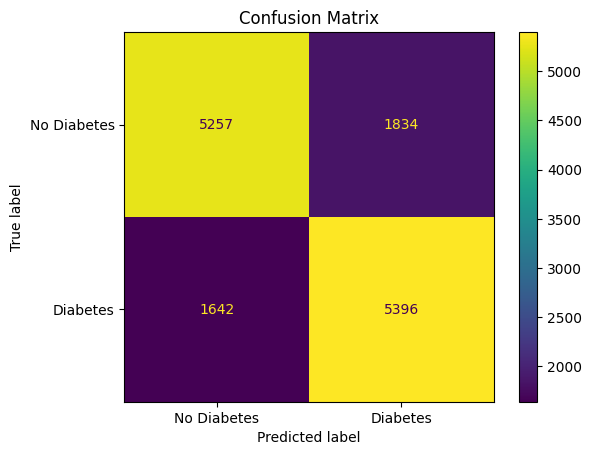

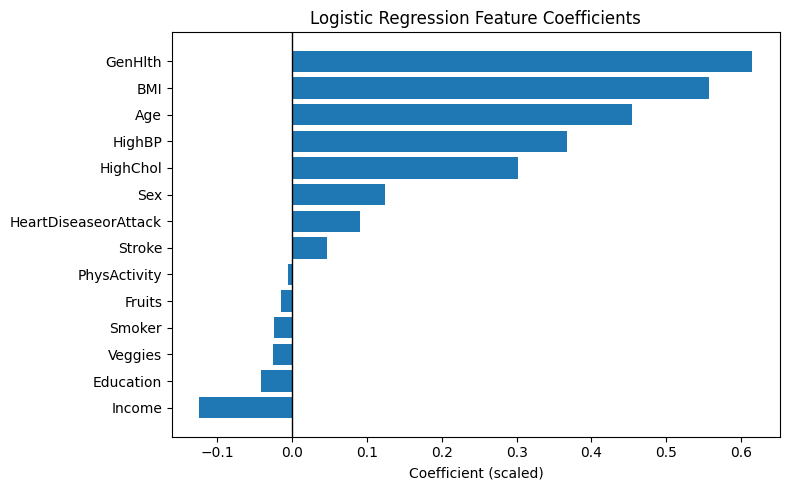

In [137]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes','Diabetes'])
disp.plot()
plt.title('Confusion Matrix')
plt.show()

#Feature weights
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')


plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient (scaled)')
plt.title('Logistic Regression Feature Coefficients')
plt.tight_layout()
plt.show()

#**Confusion Matrix**
---
###The confusion matrix for the Logistic Regression model shows that of all our samples, it accurately predicted 5257 times that a person was not diabetic, and accurately predicted 5396 times that they were diabetic. The model had 1834 false positives, where it predicted that a person had diabetes but in actuality they didn’t, and 1642 false negatives, where it failed to predict that a person had diabetes. Overall, these numbers show that the Logistic Regression model performed fairly well on the data, with an <font color = 'green'>overall accuracy of 74%</font>. Its precision and recall scores are roughly equal at around 75%, indicating that the model is good at predicting both diabetes and non-diabetes, and does not miss a large percentage of either group.


#**Feature Coefficients**
---
###For the Logistic Regression model, according to the feature coefficient plot, the features positively correlated with the patient having diabetes are General Health, BMI, Age, High Blood Pressure, High Cholesterol, Sex, Heart Disease or Attack, and Stroke. This implies that as these features increase, the likelihood of the patient having diabetes also increases. The strongest predictors, or features with the largest absolute value coefficient, are General Health, BMI, Age, High Blood Pressure, and High Cholesterol. The features negatively correlated with the patient having diabetes are Smoking, Physical Activity, Consumption of Fruits and Vegetables, Education, and Income. This implies that as these features increase, the likelihood of the patient having diabetes decreases. However, these features are not as strongly weighted as the positively correlated features, making them weaker predictors for diabetes. In conclusion, the strongest predictors of diabetes, or the largest influences on the Logistic Regression model’s classification of diabetes, are  General Health, BMI, Age, High Blood Pressure, and High Cholesterol.


___
# <font color = #585C8C> **Support Vector Machine (SVM)** </font>

In [138]:
features = ['BMI','GenHlth','Age','HighBP','HighChol','Income','Sex','Stroke','HeartDiseaseorAttack','Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'Education']

df['Diabetes'] = (df['Diabetes_binary'] == 1).astype(int)

X = df[features]
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_sub = X_train.sample(n=20000, random_state=42)
y_train_sub = y_train.loc[X_train_sub.index]

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test)

# Fit the model
model = SVC(kernel='linear', class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train_sub)
y_pred = model.predict(X_test_scaled)

print("Accuracy of Linear SVM Model:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy of Linear SVM Model: 0.7522825394578526
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74      7091
           1       0.73      0.79      0.76      7038

    accuracy                           0.75     14129
   macro avg       0.75      0.75      0.75     14129
weighted avg       0.75      0.75      0.75     14129



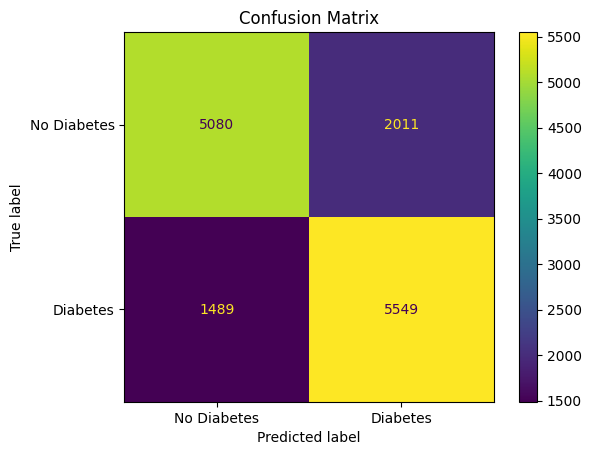

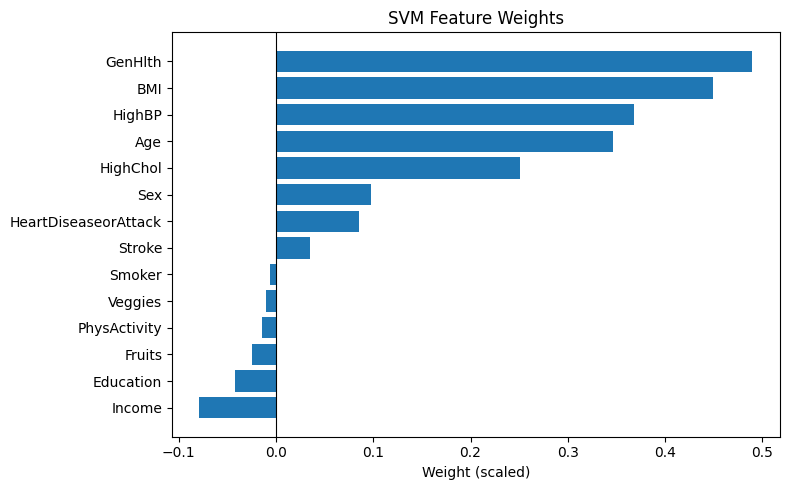

In [139]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes','Diabetes'])
disp.plot()
plt.title('Confusion Matrix')
plt.show()

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')

# Feature Weights
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Weight (scaled)')
plt.title('SVM Feature Weights')
plt.tight_layout()
plt.show()

#**Confusion Matrix**
---
###The confusion matrix for the SVM model shows that of all our samples, it accurately predicted 5080 times that a person was not diabetic, and accurately predicted 5549 times that they were diabetic. The model had 2011 false positives, where it predicted that a person had diabetes but they didn’t, and 1489 false negatives, where it failed to predict that a person had diabetes. Overall, these numbers show that the SVM model performed fairly well on the data and was very similar to the Linear Regression model. It also had an <font color = 'green'> overall accuracy of 74% </font>, and the SVMs precision and recall scores varied slightly more from each other than the ones from the Linear Regression model. The SVM’s higher recall rate is important when looking at predicting health issues because it means that the model is less likely to miss identify a person with diabetes, so medical professionals can provide more people treatment, at an earlier time.

#**Feature Coefficients**
---
###The SVM model has a very similar feature weight plot to the Logistic regression model, with slightly different weights for a few features due to calculation differences. However, the models have the same strongest predictors of diabetes and shape concerning which features are positively and negatively correlated to the patient having diabetes.

#**<font color = #E33B3B> Insights and Conclusions </font>**
___

###Diabetes is one of the most prevalent chronic diseases in America, affecting an estimated 40.1 million people in the United States, or around <font color = 'red'> 12% </font> of the U.S. population.  Our observations from our modeling and visualization were able to pinpoint several key features that seem to impact diabetes the most. Some of the most important features we identified was a person’s overall health, BMI, Age, whether they have high blood pressure, and whether they have high cholesterol levels. Given that in both of our models we see these 5 features as the top features, it is safe to say that these are some of the most important features in determining diabetes, to help identify and provide treatment.

###In determining a person’s risk for diabetes, we see that the groups who had the best overall health typically had lower rates of diabetes than those who had worse overall health. Similarly, people who fall under the healthy BMI category also have lower rates. Looking at both our boxplot, and histogram for age we can see the trend that people are more likely to develop diabetes as they get older. Finally we also see that having high blood pressure, or high cholesterol levels, puts a person more at risk of having diabetes.

###From these conclusions, we can draw how important it is to monitor your overall health to help prevent diabetes. Most of our important features were based upon a person’s health, with the only one not directly related being age, which still can have an impact on a person’s overall health, because typically as people get older their health deteriorates. Overall, our analysis should be able to help people by informing them of the importance of health and common signs of diabetes, so that they can receive early treatment to prevent other serious illnesses and live a healthier lifestyle.


##**Sources**:
###For additional exploration, check out these links:
###[Original dataset](https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system) and the [diabetes dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data?select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv) that we used
* The original dataset leads to the CDC Behavioral Risk Factor Surveillance System survey, and the diabetes dataset is what we used for this project
###[What Is a Data Science Pipeline? A Complete Guide - Domo](https://www.domo.com/glossary/what-is-the-data-science-pipeline)
###[What is logistic regression? - IBM](https://www.ibm.com/think/topics/logistic-regression)
###[What are SVMs? - IBM](https://www.ibm.com/think/topics/support-vector-machine)
###[Hypothesis tests - PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC7807926/)
###[Enhancing Diabetes Diagnosis Through Machine Learning: A Comparative Study - MDPI](https://www.mdpi.com/3500248)
* An additional academic study that uses multiple machine learning models and techniques to diagnose Diabetes
